In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cell line data:

In [3]:
gen1_rna = pd.read_csv("data/GSM7454074_V350003741_L01_87.txt", sep=" ")
gen1_rna

,Gene,rpkm
0,A1BG,0.112543
1,A1BG-AS1,0.119130
2,A1CF,1.549091
3,A2M,0.010662
4,A2M-AS1,0.330974
...,...,...
28247,ZYG11A,2.033434
28248,ZYG11B,2.009905
28249,ZYX,78.470510
28250,ZZEF1,4.789009


In [10]:
len(set(gen1_rna["Gene"]))

28252

In [4]:
gen1_rna[gen1_rna["rpkm"]>0]

,Gene,rpkm
0,A1BG,0.045567
1,A1BG-AS1,0.144701
2,A1CF,2.876157
4,A2M-AS1,0.120605
8,A4GALT,51.752590
...,...,...
28247,ZYG11A,2.277216
28248,ZYG11B,3.145334
28249,ZYX,73.462420
28250,ZZEF1,6.195968


In [7]:
string_info = pd.read_csv("9606.protein.info.v12.0.txt", sep="\t")
string_info.head()

,#string_protein_id,preferred_name,protein_size,annotation
0,9606.ENSP00000000233,ARF5,180,ADP-ribosylation factor 5; GTP-binding protein...
1,9606.ENSP00000000412,M6PR,277,Cation-dependent mannose-6-phosphate receptor;...
2,9606.ENSP00000001008,FKBP4,459,"Peptidyl-prolyl cis-trans isomerase FKBP4, N-t..."
3,9606.ENSP00000001146,CYP26B1,512,Cytochrome P450 26B1; Involved in the metaboli...
4,9606.ENSP00000002125,NDUFAF7,441,"Protein arginine methyltransferase NDUFAF7, mi..."


In [8]:
string_alias = pd.read_csv("9606.protein.aliases.v12.0.txt", sep="\t")
string_alias.head()

,#string_protein_id,alias,source
0,9606.ENSP00000000233,2B6H,Ensembl_PDB
1,9606.ENSP00000000233,2B6H,UniProt_DR_PDB
2,9606.ENSP00000000233,381,Ensembl_HGNC_entrez_id
3,9606.ENSP00000000233,381,KEGG_GENEID
4,9606.ENSP00000000233,381,KEGG_KEGGID_SHORT


In [9]:
len(string_info["preferred_name"])

19699

In [11]:
direct_intersect = set(string_info["preferred_name"])&set(gen1_rna["Gene"])
len(direct_intersect)

19069

In [12]:
mapping = string_info[string_info["preferred_name"].isin(direct_intersect)]
len(mapping)

19069

In [13]:
string_rem = set(string_info["preferred_name"])-set(gen1_rna["Gene"])
genes_rem = set(gen1_rna["Gene"])-set(string_info["preferred_name"])

len(string_rem), len(genes_rem)

(630, 9183)

In [14]:
string_alias_rem = string_alias[~string_alias["#string_protein_id"].isin(mapping["#string_protein_id"])]
len(set(string_alias_rem["#string_protein_id"]))

630

In [15]:
alias_intersect = genes_rem&set(string_alias_rem["alias"])
len(alias_intersect)

159

In [16]:
alias_map = string_alias_rem[string_alias_rem["alias"].isin(list(alias_intersect))]
alias_map

,#string_protein_id,alias,source
154412,9606.ENSP00000231572,RARS,Ensembl_HGNC_prev_symbol
154413,9606.ENSP00000231572,RARS,Ensembl_UniProt
154414,9606.ENSP00000231572,RARS,Ensembl_external_synonym_HGNC
154415,9606.ENSP00000231572,RARS,KEGG_NAME_SYNONYM
154416,9606.ENSP00000231572,RARS,UniProt_GN_Synonyms
...,...,...,...
3882009,9606.ENSP00000500220,ARSE,UniProt_GN_Synonyms
3886322,9606.ENSP00000501088,C21orf59-TCP10L,Ensembl_EntrezGene
3886323,9606.ENSP00000501088,C21orf59-TCP10L,Ensembl_WikiGene
3886324,9606.ENSP00000501088,C21orf59-TCP10L,KEGG_NAME_SYNONYM


In [17]:
alias_map = alias_map[["#string_protein_id", "alias"]].drop_duplicates()
alias_map

,#string_protein_id,alias
154412,9606.ENSP00000231572,RARS
205291,9606.ENSP00000244534,HIST1H1D
205926,9606.ENSP00000244537,HIST1H4A
205929,9606.ENSP00000244537,HIST1H4B
205930,9606.ENSP00000244537,HIST1H4C
...,...,...
3858096,9606.ENSP00000498497,SPDYE14P
3860011,9606.ENSP00000498596,TMEM173
3877410,9606.ENSP00000499501,HIST2H3PS2
3882005,9606.ENSP00000500220,ARSE


In [27]:
alias_map.to_excel("remaining_to_map.xlsx", index=False)

In [77]:
alias_map = pd.read_excel("remaining_to_map.xlsx")

In [79]:
len(alias_map), len(set(alias_map["#string_protein_id"])), len(set(alias_map["alias"]))

(160, 160, 159)

In [80]:
aux = alias_map.groupby("#string_protein_id").count()
aux[aux['alias']>1]

,alias
#string_protein_id,


In [81]:
aux = alias_map.groupby("alias").count()
aux[aux['#string_protein_id']>1]

,#string_protein_id
alias,
SARS,2


In [83]:
alias_map[alias_map["alias"]=="SARS"]

,#string_protein_id,alias
70,9606.ENSP00000358939,SARS
114,9606.ENSP00000472465,SARS


In [84]:
string_info[string_info["#string_protein_id"].isin(["9606.ENSP00000358939", "9606.ENSP00000472465"])]

,#string_protein_id,preferred_name,protein_size,annotation
10290,9606.ENSP00000358939,SARS1,536,"Serine--tRNA ligase, cytoplasmic; Catalyzes th..."
17671,9606.ENSP00000472465,SARS2-2,588,Uncharacterized protein.


In [88]:
for gene in gen1_rna["Gene"]:
    if "SARS" in gene:
        print(gene)

SARS
SARS2


In [89]:
# drop sars2-2
alias_map = alias_map.drop(index=114)

In [90]:
aux = alias_map.groupby("alias").count()
aux[aux['#string_protein_id']>1]

,#string_protein_id
alias,


In [91]:
mapping = mapping[["#string_protein_id", "preferred_name"]]
alias_map.columns = ["#string_protein_id", "preferred_name"]
mapping_final = pd.concat([mapping,alias_map], ignore_index=True)

In [93]:
len(set(mapping_final["preferred_name"])), len(set(mapping_final["#string_protein_id"])), len(mapping_final)

(19228, 19228, 19228)

In [94]:
mapping_final.to_csv("human_MHCC97H_gene_to_string_mapping.csv", index=False)

In [98]:
gen1_rna = gen1_rna.set_index("Gene")
gen1_rna.T

Gene,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2MP1,A3GALT2,A4GALT,A4GNT,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
rpkm,0.045567,0.144701,2.876157,0.0,0.120605,0.0,0.0,0.0,51.75259,0.03465,...,8.082724,14.40624,2.943535,6.357598,8.838002,2.277216,3.145334,73.46242,6.195968,6.248848


In [3]:
samples = ["GSM7454068_V350003741_L01_81.txt", "GSM7454069_V350003741_L01_82.txt", "GSM7454070_V350003741_L01_83.txt",
          "GSM7454071_V350003741_L01_84.txt", "GSM7454072_V350003741_L01_85.txt", "GSM7454073_V350003741_L01_86.txt",
          "GSM7454074_V350003741_L01_87.txt", "GSM7454075_V350003741_L01_88.txt", "GSM7454076_V350003741_L01_73.txt"]

for sample in samples:
    df = pd.read_csv("data/"+sample, sep=" ")
    print(len(df[df["rpkm"]>0]))

18540
19072
18815
18941
18866
18973
19047
19104
18932


In [4]:
d = {}
for sample in samples:
    network = pd.read_csv("network_data/"+sample[:-4]+"_0_network.csv")
    d[sample] = set(network["protein1"])|set(network["protein2"])

In [6]:
for item in d:
    print(len(d[item]))

6806
6935
6888
6906
6932
6939
6967
6948
6901


In [13]:
intersect = d[samples[0]]
for item in d:
    intersect = intersect&d[item]

In [14]:
len(intersect)

6453

~ 400 proteins differ overall

In [2]:
network = pd.read_csv("network_data/GSM7454068_V350003741_L01_81_0_network.csv")
network

,protein1,protein2,experiments,database,combined_score,protein1_name,protein2_name,rpkm_x,rpkm_y
0,9606.ENSP00000000412,9606.ENSP00000349437,0,900,900,M6PR,IGF2R,90.727700,35.230860
1,9606.ENSP00000438085,9606.ENSP00000349437,960,0,972,GGA3,IGF2R,27.030710,35.230860
2,9606.ENSP00000000412,9606.ENSP00000438085,960,0,970,M6PR,GGA3,90.727700,27.030710
3,9606.ENSP00000272317,9606.ENSP00000438085,926,0,926,RPS27A,GGA3,585.293300,27.030710
4,9606.ENSP00000311962,9606.ENSP00000438085,691,900,975,GGA2,GGA3,22.508330,27.030710
...,...,...,...,...,...,...,...,...,...
110109,9606.ENSP00000500386,9606.ENSP00000309245,900,400,990,CAMK2A,LRRC7,0.044604,0.016642
110110,9606.ENSP00000500409,9606.ENSP00000371897,0,900,900,ARHGAP35,ARHGAP5,29.361310,19.646500
110111,9606.ENSP00000500986,9606.ENSP00000380352,0,900,900,DDHD1,DDHD2,1.583747,7.290462
110112,9606.ENSP00000501111,9606.ENSP00000337354,0,900,900,CEL,LIPA,0.155401,22.814780


<Axes: >

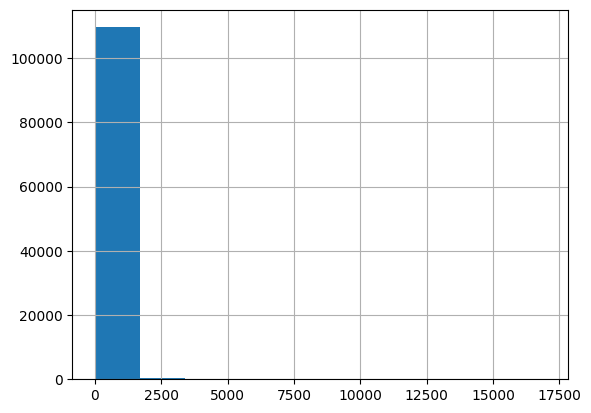

In [3]:
network["rpkm_x"].hist()

<Axes: >

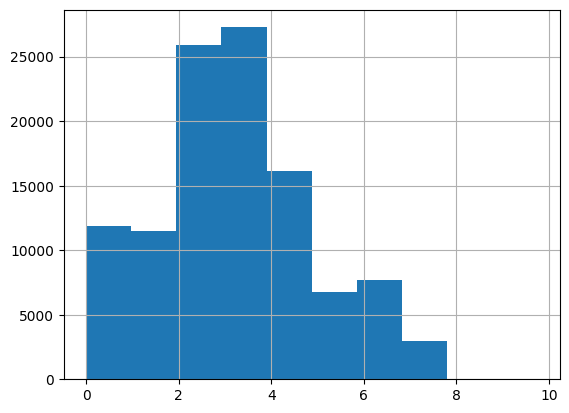

In [7]:
np.log(network["rpkm_x"]+1).hist()

<Axes: >

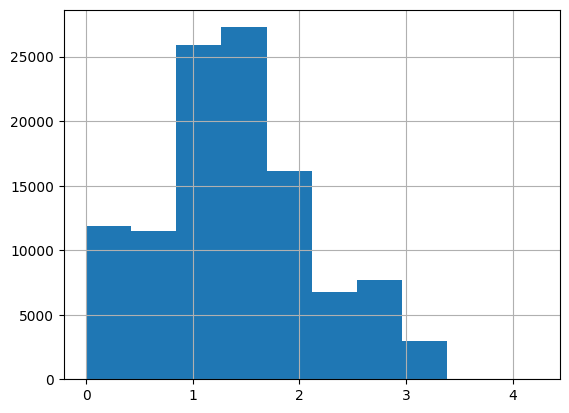

In [8]:
np.log10(network["rpkm_x"]+1).hist()

___

# Embryogenesis data:

In [13]:
data = pd.read_csv("data/GSE121160_RAW/GSM3427100_00h_1.tsv.gz", sep="\t", header=None)
data = data.set_index(0).T
data

,FBgn0000003,FBgn0000008,FBgn0000014,FBgn0000015,FBgn0000017,FBgn0000018,FBgn0000022,FBgn0000024,FBgn0000028,FBgn0000032,...,FBgn0267791,FBgn0267792,FBgn0267793,FBgn0267794,FBgn0267795,no_feature,ambiguous,too_low_aQual,not_aligned,alignment_not_unique
1,0,677,232,77,4827,202,33,57,5,2631,...,2514,1402,1,0,1601,93389,321979,0,0,749217


In [15]:
import os

genes = set(data.columns)

files = os.listdir("data/GSE121160_RAW/")
for file in files:
    data = pd.read_csv("data/GSE121160_RAW/"+file, sep="\t", header=None)
    data = data.set_index(0).T
    genes = genes|set(data.columns)

In [16]:
len(genes)
## genes/cols are the same in each file
## -5 = 17558 genes; 5 additional info cols

17563

In [18]:
aliases = pd.read_csv("data/7227.protein.aliases.v12.0.txt", sep="\t")
aliases

,#string_protein_id,alias,source
0,7227.FBpp0070001,33009,Ensembl_EntrezGene
1,7227.FBpp0070001,33009,KEGG_GENEID
2,7227.FBpp0070001,33009,UniProt_DR_GeneID
3,7227.FBpp0070001,7227.FBpp0070001,Ensembl_STRING
4,7227.FBpp0070001,AAF45383.1,Ensembl_protein_id
...,...,...,...
854247,7227.FBpp0423328,FBtr0475226,Ensembl_flybase_transcript_id
854248,7227.FBpp0423328,FBtr0475226,Ensembl_transcript
854249,7227.FBpp0423328,NP_001369062,KEGG_NCBI
854250,7227.FBpp0423328,Uncharacterized protein,KEGG_PRODUCT


In [32]:
intersect = set(aliases["alias"])&genes
len(intersect)

13745

In [30]:
aux1 = aliases[(aliases["alias"].isin(genes))][["#string_protein_id","alias"]].drop_duplicates()
aux1

,#string_protein_id,alias
18,7227.FBpp0070001,FBgn0031085
46,7227.FBpp0070002,FBgn0062565
103,7227.FBpp0070005,FBgn0031089
164,7227.FBpp0070006,FBgn0031092
204,7227.FBpp0070007,FBgn0031094
...,...,...
853970,7227.FBpp0423288,FBgn0263376
853988,7227.FBpp0423289,FBgn0266811
854056,7227.FBpp0423293,FBgn0039523
854181,7227.FBpp0423324,FBgn0263324


In [31]:
aux2 = aliases[(aliases["alias"].isin(genes))&(aliases["source"]=="Ensembl_flybase_gene_id")]
aux2

,#string_protein_id,alias,source
18,7227.FBpp0070001,FBgn0031085,Ensembl_flybase_gene_id
46,7227.FBpp0070002,FBgn0062565,Ensembl_flybase_gene_id
103,7227.FBpp0070005,FBgn0031089,Ensembl_flybase_gene_id
164,7227.FBpp0070006,FBgn0031092,Ensembl_flybase_gene_id
204,7227.FBpp0070007,FBgn0031094,Ensembl_flybase_gene_id
...,...,...,...
853970,7227.FBpp0423288,FBgn0263376,Ensembl_flybase_gene_id
853988,7227.FBpp0423289,FBgn0266811,Ensembl_flybase_gene_id
854056,7227.FBpp0423293,FBgn0039523,Ensembl_flybase_gene_id
854181,7227.FBpp0423324,FBgn0263324,Ensembl_flybase_gene_id


In [29]:
aliases[(aliases["alias"].isin(genes))].groupby("source").count()

,#string_protein_id,alias
source,,
Ensembl_flybase_gene_id,13743,13743
Ensembl_gene,13743,13743
UniProt_DR_FlyBase,13686,13686
UniProt_GN_Name,4,4
UniProt_GN_ORFNames,1,1
UniProt_GN_Synonyms,30,30


In [36]:
len(set(aux2["alias"])), len(set(aux2["#string_protein_id"]))

(13743, 13743)

In [37]:
intersect-set(aux2["alias"])

{'FBgn0027885', 'FBgn0028974'}

In [38]:
len(set(aux1["alias"])), len(set(aux1["#string_protein_id"]))

(13745, 13745)

In [39]:
grouped = aux1.groupby("alias").count()
grouped[grouped["#string_protein_id"]>1]

,#string_protein_id
alias,
FBgn0000078,2
FBgn0010358,2
FBgn0013275,2
FBgn0013277,2
FBgn0020644,2
...,...
FBgn0267044,2
FBgn0267049,2
FBgn0267050,2


In [40]:
aux1[aux1["alias"]=="FBgn0000078"]

,#string_protein_id,alias
361970,7227.FBpp0086136,FBgn0000078
805414,7227.FBpp0311627,FBgn0000078


In [41]:
aliases[aliases["alias"]=="FBgn0000078"]
## by name, the ensembl is the correct

,#string_protein_id,alias,source
361970,7227.FBpp0086136,FBgn0000078,Ensembl_flybase_gene_id
361971,7227.FBpp0086136,FBgn0000078,Ensembl_gene
805414,7227.FBpp0311627,FBgn0000078,UniProt_DR_FlyBase


In [42]:
aliases[aliases["alias"].isin(['FBgn0027885', 'FBgn0028974'])]

,#string_protein_id,alias,source
232711,7227.FBpp0080554,FBgn0027885,UniProt_DR_FlyBase
853136,7227.FBpp0423201,FBgn0028974,UniProt_DR_FlyBase


In [43]:
aux2[aux2["#string_protein_id"].isin(["7227.FBpp0080554","7227.FBpp0423201"])]

,#string_protein_id,alias,source


In [47]:
aliases[aliases["#string_protein_id"]=="7227.FBpp0423201"].head(30)
## FBgn0027885 --> wrong mapping --> exclude
## FBgn0028974 --> wrong mapping --> exclude
## aux2: based on ensembl flybase gene id is a good mapping

,#string_protein_id,alias,source
853120,7227.FBpp0423201,44271,Ensembl_EntrezGene
853121,7227.FBpp0423201,44271,KEGG_GENEID
853122,7227.FBpp0423201,44271,UniProt_DR_GeneID
853123,7227.FBpp0423201,7227.FBpp0074178,Ensembl_STRING
853124,7227.FBpp0423201,7227.FBpp0074179,Ensembl_STRING
853125,7227.FBpp0423201,A0A4D6K557,Ensembl_UniProt
853126,7227.FBpp0423201,AAF23814.1,Ensembl_protein_id
853127,7227.FBpp0423201,AAF23815.1,Ensembl_protein_id
853128,7227.FBpp0423201,AAF48702.2,Ensembl_protein_id
853129,7227.FBpp0423201,AAN09434.1,Ensembl_protein_id


In [49]:
aux2[["#string_protein_id","alias"]].to_csv("data/drosophila_m_gene_mapping.csv", index=False)